In [3]:
# Imporing required Python Libraries

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
# Loading Dataset from local disk

df=pd.read_csv("Zomato-data-.csv")

In [7]:
df.head() # printing first 5 rows from dataset to understand columns and eda process.

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [10]:
# converting rate column eg. 4.1/5 ( object values) to 4.1 ( float)

def HandleRate(value):
    value=str(value).split("/")
    value=value[0]
    return float(value)

df["rate"]=df["rate"].apply(HandleRate)
df.head(5)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [11]:
# dataset info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 12.0 KB


In [12]:
# Checking for missing or null values

df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

AttributeError: module 'matplotlib.pyplot' has no attribute 'xlable'

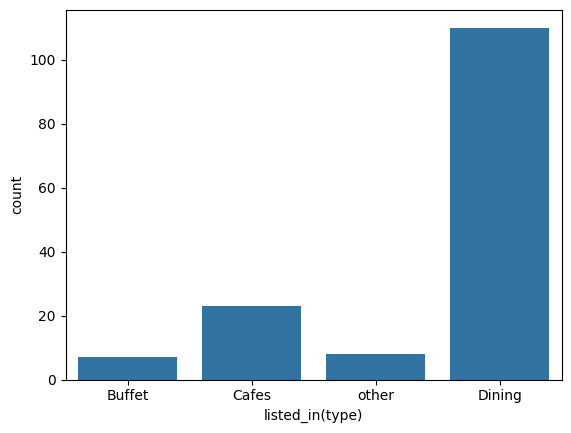

In [14]:
# 1. finding top restaurant category using listed_in(Type) column

sns.countplot(x=df["listed_in(type)"])
plt.xlable("Type of Restaurant")

**1. Conclusion**: Most of the restaurant falls under Dining Category.

Text(0, 0.5, 'Votes')

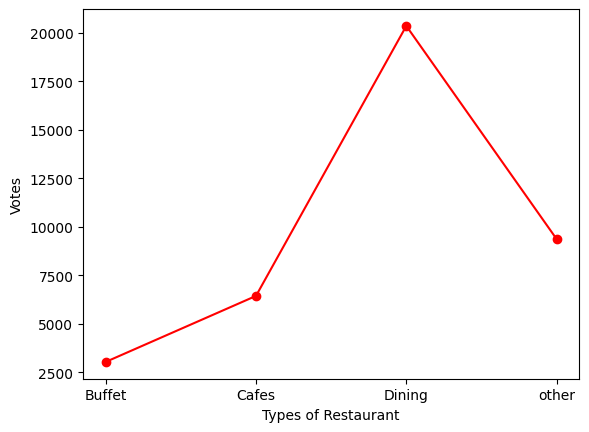

In [17]:
# 2. Vote by Restaurant Type

grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame({"votes":grouped_data})
plt.plot(result, c="red", marker="o")
plt.xlabel("Types of Restaurant")
plt.ylabel("Votes")

**2. Conclusion**: Larger number of people likes Dining Restaurants.

In [18]:
# 3.Identifing Most voted Restaurants

max_votes=df["votes"].max()
restaurant_with_max_votes=df.loc[df["votes"]== max_votes, "name"]

print("Restaurant with max votes")
print(restaurant_with_max_votes)

Restaurant with max votes
38    Empire Restaurant
Name: name, dtype: str


<Axes: xlabel='online_order', ylabel='count'>

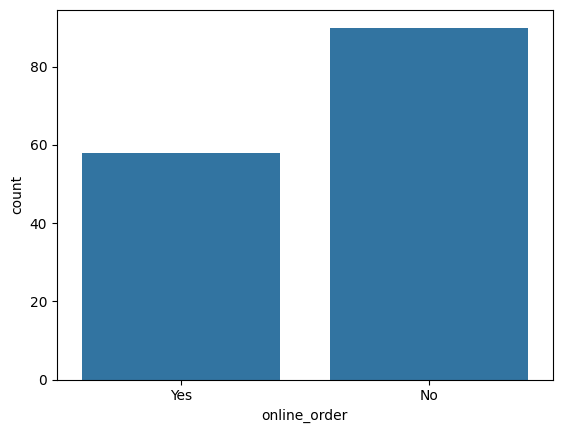

In [19]:
# 4. Online order availabilty

sns.countplot(x=df["online_order"])

**4. Conclusion**: Most of the restaurants will not accept online orders.

<function matplotlib.pyplot.show(close=None, block=None)>

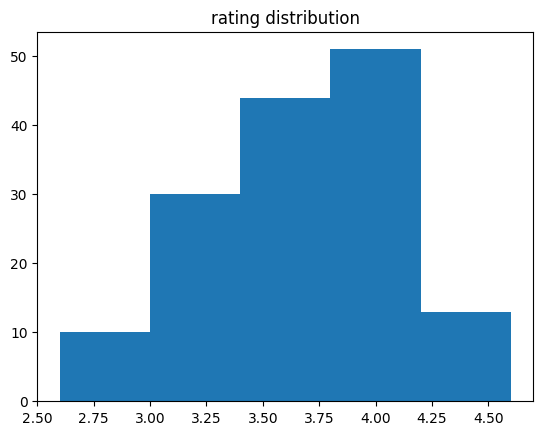

In [21]:
# 5. Analysing the rating 

plt.hist(df["rate"], bins=5)
plt.title("rating distribution")
plt.show

**5. Conclusion**: more restaurants got 3.4 to 4.2 ratings.

Task was destroyed but it is pending!
task: <Task pending name='Task-362' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\ADMIN\AppData\Roaming\Python\Python311\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-363' coro=<Kernel.shell_main() running at C:\Users\ADMIN\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\ADMIN\AppData\Roaming\Python\Python311\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\ADMIN\AppData\Roaming\Python\Python311\site-packages\cycler\__init__.py:262: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  yield dict(left)
Task was destroyed but it is pending!
task: <Task pending name='Task-363' coro=<Kernel.shell_main() running at C:\Users\ADMIN\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

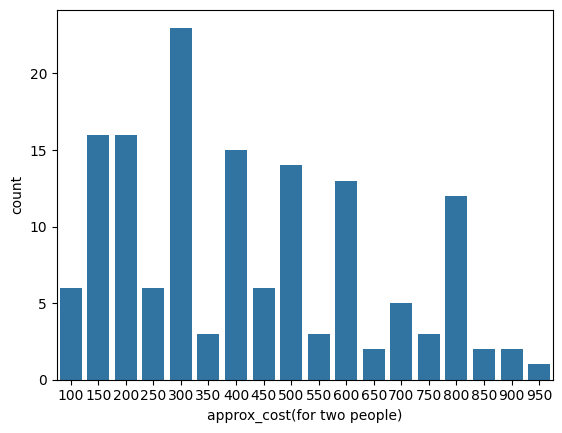

In [22]:
# Approximate cost for couples. (to know prefreed price range).

sns.countplot(x=df["approx_cost(for two people)"])

**6.Conclusion**: Most of the couples prefer restaurants with cost of 300.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19136\707129693.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([online, offline], labels=["Yes", "No"])


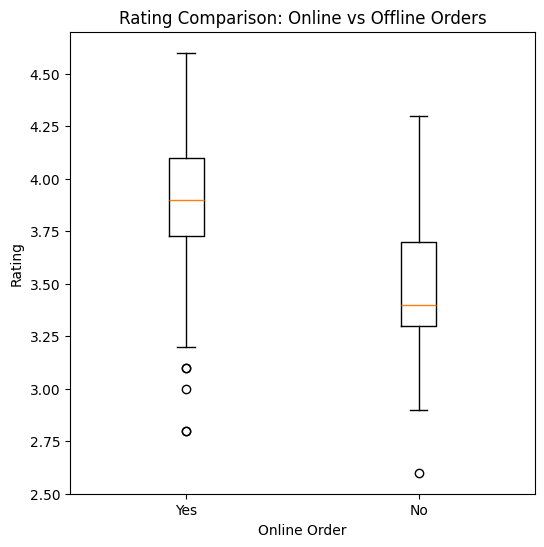

In [27]:
#7. Rating comparision - online vs offline orders.

online = df[df["online_order"] == "Yes"]["rate"]
offline = df[df["online_order"] == "No"]["rate"]

plt.figure(figsize=(6,6))
plt.boxplot([online, offline], labels=["Yes", "No"])
plt.xlabel("Online Order")
plt.ylabel("Rating")
plt.title("Rating Comparison: Online vs Offline Orders")
plt.show()

**7.Conclusion**: Online orders recieve higher votes compared to offline rating.

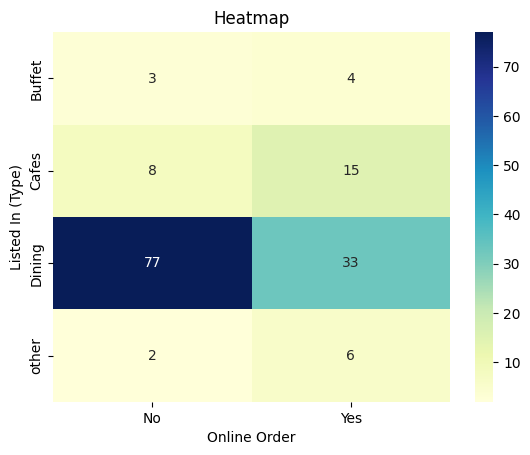

In [28]:
# Order mode prefernece by restaurant type: 

pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

**8. conlusion**: Dining restaurants primarily reley on offline orders where as cafes relay on online orders.